# Chapter 7 — Charge density of GaAs in the (1-10) plane

Companion notebook to Chapter 7. We plot the valence charge density that
`pp.x` extracted on a 2D cut through the (1̄1̅0) plane
(`code/07-charge/gaas.rho_110.dat`), the plane that contains the Ga–As
bonds, and overlay the atom positions. Requirements: `numpy`, `matplotlib`.

In [1]:
import numpy as np
from pathlib import Path

BOHR = 0.52917721
d = Path('../code/07-charge')

# pp.x gnuplot 2D format: columns x, y, rho on a regular nx*ny grid (bohr).
raw = np.loadtxt(d/'gaas.rho_110.dat')
x, y, rho = raw[:, 0], raw[:, 1], raw[:, 2]
ny = np.sum(x == x[0])            # points sharing the first x value
nx = len(x) // ny
X = (x.reshape(nx, ny)) * BOHR
Y = (y.reshape(nx, ny)) * BOHR
R = rho.reshape(nx, ny)
print(f'grid {nx} x {ny};  rho range {R.min():.2f} .. {R.max():.2f} e/bohr^3')

grid 180 x 130;  rho range 0.00 .. 1.51 e/bohr^3


In [2]:
# Atoms lying in the plane: spanned by e1=(1,1,0)/sqrt2, e2=(0,0,1), origin at Ga.
# An atom at (rx,ry,rz) (alat units) is in-plane iff rx == ry; then
#   x_plot = (rx+ry)/sqrt(2) * alat,  y_plot = rz * alat.
import itertools
alat_A = 10.6829 * BOHR
fcc = [(0,0,0),(0.5,0.5,0),(0.5,0,0.5),(0,0.5,0.5),
       (1,1,0),(1,0,1),(0,1,1),(1,1,1),(0.5,0.5,1),(1,0.5,0.5),(0.5,1,0.5)]
def in_plane(basis):
    pts=[]
    for t in fcc:
        r=np.array(basis)+np.array(t)
        if abs(r[0]-r[1])<1e-6:
            xp=(r[0]+r[1])/np.sqrt(2)*alat_A; yp=r[2]*alat_A
            if -0.1<=xp<=X.max()+0.1 and -0.1<=yp<=Y.max()+0.1: pts.append((xp,yp))
    return pts
ga = in_plane((0,0,0)); asat = in_plane((0.25,0.25,0.25))
print('Ga in-plane:', [(round(a,2),round(b,2)) for a,b in ga])
print('As in-plane:', [(round(a,2),round(b,2)) for a,b in asat])

Ga in-plane: [(0.0, 0.0), (4.0, 0.0), (7.99, 0.0), (7.99, 5.65), (4.0, 5.65)]
As in-plane: [(2.0, 1.41), (6.0, 1.41)]


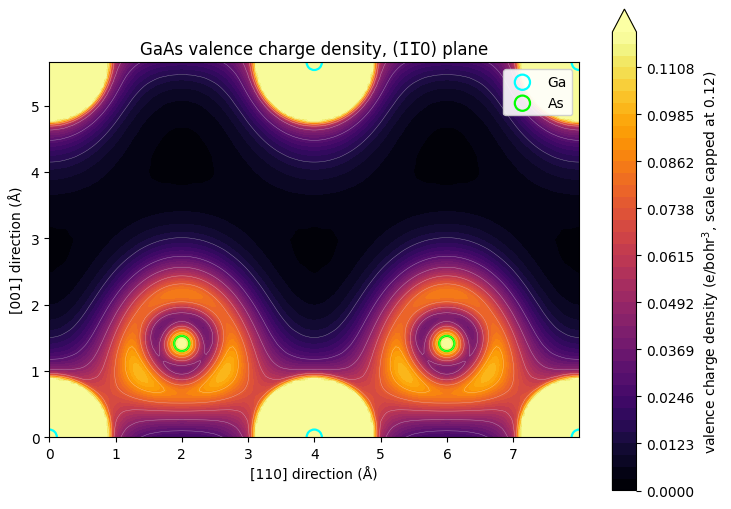

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7.5, 5.2))
# The Ga 3d semicore charge towers to ~1.5 e/bohr^3 and would wash out the
# bonding charge. Saturate the colour scale low to reveal the Ga-As bond.
vmax = 0.12
levels = np.linspace(0, vmax, 40)
cf = ax.contourf(X, Y, np.clip(R, 0, vmax), levels=levels, cmap='inferno', extend='max')
ax.contour(X, Y, np.clip(R, 0, vmax), levels=10, colors='white', linewidths=0.3, alpha=0.5)
fig.colorbar(cf, ax=ax, label='valence charge density (e/bohr$^3$, scale capped at 0.12)')

gx, gy = zip(*ga); ax_x, ax_y = zip(*asat)
ax.scatter(gx, gy, s=120, facecolors='none', edgecolors='cyan', linewidths=1.6, label='Ga')
ax.scatter(ax_x, ax_y, s=120, facecolors='none', edgecolors='lime', linewidths=1.6, label='As')
ax.set_xlabel('[110] direction (Å)')
ax.set_ylabel('[001] direction (Å)')
ax.set_title('GaAs valence charge density, (1̄1̅0) plane')
ax.set_aspect('equal'); ax.legend(loc='upper right', framealpha=0.9)
fig.tight_layout()
fig.savefig(d.parent.parent/'static/img/07-charge.png', dpi=120)
plt.show()

**What you see.** A note on the colour scale: because this Ga
pseudopotential keeps the **3d semicore** in valence, the raw density
spikes to ~1.5 e/bohr³ right at the Ga sites and would otherwise wash out
everything else — so we cap the scale at 0.12 to reveal the chemistry.
With that done, the key feature appears: a **ridge of charge between each
Ga and its As neighbours** — the covalent bond, running along the [111]
direction in this plane. The bond charge sits closer to the more
electronegative **As**; that ionic asymmetry is what makes GaAs *polar*
(and underlies the LO–TO splitting we'll meet with phonons). This is the
real-space complement to the band/PDOS picture: the same valence
electrons, now shown as *where they sit*.

The 3D density `gaas.rho.xsf` (also written by `pp.x`) can be opened in
**VESTA** or **XCrySDen** to see the bonds as isosurfaces in 3D.